# Single Cylinder Demo — Re = 10⁶

Compact demonstration of `VortexAmp` for one cylinder (D = 1 m) at high Reynolds number.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import SymLogNorm
from scipy import signal

from vortex_amp import (VortexAmp, compute_velocity_field,
                        compute_strouhal_number, compute_drag_coefficient)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

# Physical parameters
D = 1.0              # Cylinder diameter [m]
NU = 1.14e-6         # Kinematic viscosity [m²/s]
RE = 1e6             # Target Reynolds number
U_INF = RE * NU / D  # Free-stream velocity [m/s]

# Domain sizing (in diameters)
X_MIN, X_MAX = -5 * D, 40 * D
Y_MIN, Y_MAX = -5 * D,  5 * D

# Derived
ST = compute_strouhal_number(RE)
CD = compute_drag_coefficient(RE)
F_SHED = ST * U_INF / D
T_SHED = 1.0 / F_SHED

print(f'U_inf  = {U_INF:.3f} m/s')
print(f'Re     = {RE:.0e}')
print(f'St     = {ST:.3f}')
print(f'C_D    = {CD:.3f}')
print(f'f_shed = {F_SHED:.4f} Hz  (T = {T_SHED:.3f} s)')

U_inf  = 1.140 m/s
Re     = 1e+06
St     = 0.200
C_D    = 0.807
f_shed = 0.2280 Hz  (T = 4.386 s)


In [18]:
# Cylinder and probe definitions
cylinders = [{'x': 0.0, 'y': 0.0, 'D': D}]

measurement_points = [
    ( 3 * D, 0.0),     # Near wake, centreline
    ( 8 * D, 0.0),     # Mid wake, centreline
    (20 * D, 0.0),     # Far wake, centreline
    ( 8 * D, 1.0 * D), # Mid wake, off-centre
]

# Simulation timing
DT = 0.005
TOTAL_TIME = 60 * T_SHED   # ~60 shedding cycles
SAVE_INTERVAL = T_SHED     # save one snapshot per shedding period
OUTPUT_DIR = 'output/demo_single'

print(f'Total time   = {TOTAL_TIME:.1f} s  ({TOTAL_TIME/T_SHED:.0f} shedding cycles)')
print(f'Steps        = {int(TOTAL_TIME/DT)}')
print(f'Save interval= {SAVE_INTERVAL:.3f} s')

Total time   = 263.2 s  (60 shedding cycles)
Steps        = 52631
Save interval= 4.386 s


In [19]:
# Run simulation
sim = VortexAmp(
    cylinders=cylinders,
    nu=NU,
    flow_angle_metocean=270.0,   # left → right
    rotation_angle=0.0,
    x_removal=X_MAX + 2 * D,
    dt=DT,
    measurement_points=measurement_points,
    save_interval=SAVE_INTERVAL,
    sigma_max_factor=None,
    turbulent_viscosity_ratio=800.0,  
    output_base_dir=OUTPUT_DIR,
)

results = sim.run(
    velocity_mode='constant',
    U_inf=U_INF,
    total_time=TOTAL_TIME,
    output_dir=OUTPUT_DIR,
)

sim.save_results('demo_results.pkl')
print(f'Results shape: {results.shape}')

Output directory: output/demo_single
Starting vortex method simulation...
  Initial velocity U_inf(0) = 1.140 m/s
  Initial Reynolds Re(0) = 1.00e+06
  Strouhal number St(0) = 0.200
  Initial shedding period = 4.386 s



Simulating: 100%|██████████| 52631/52631 [00:08<00:00, 6079.22step/s]

Simulation complete. Total vortices in domain: 17
Results saved to output/demo_single\demo_results.pkl
Results shape: (52631, 18)


## Velocity Field

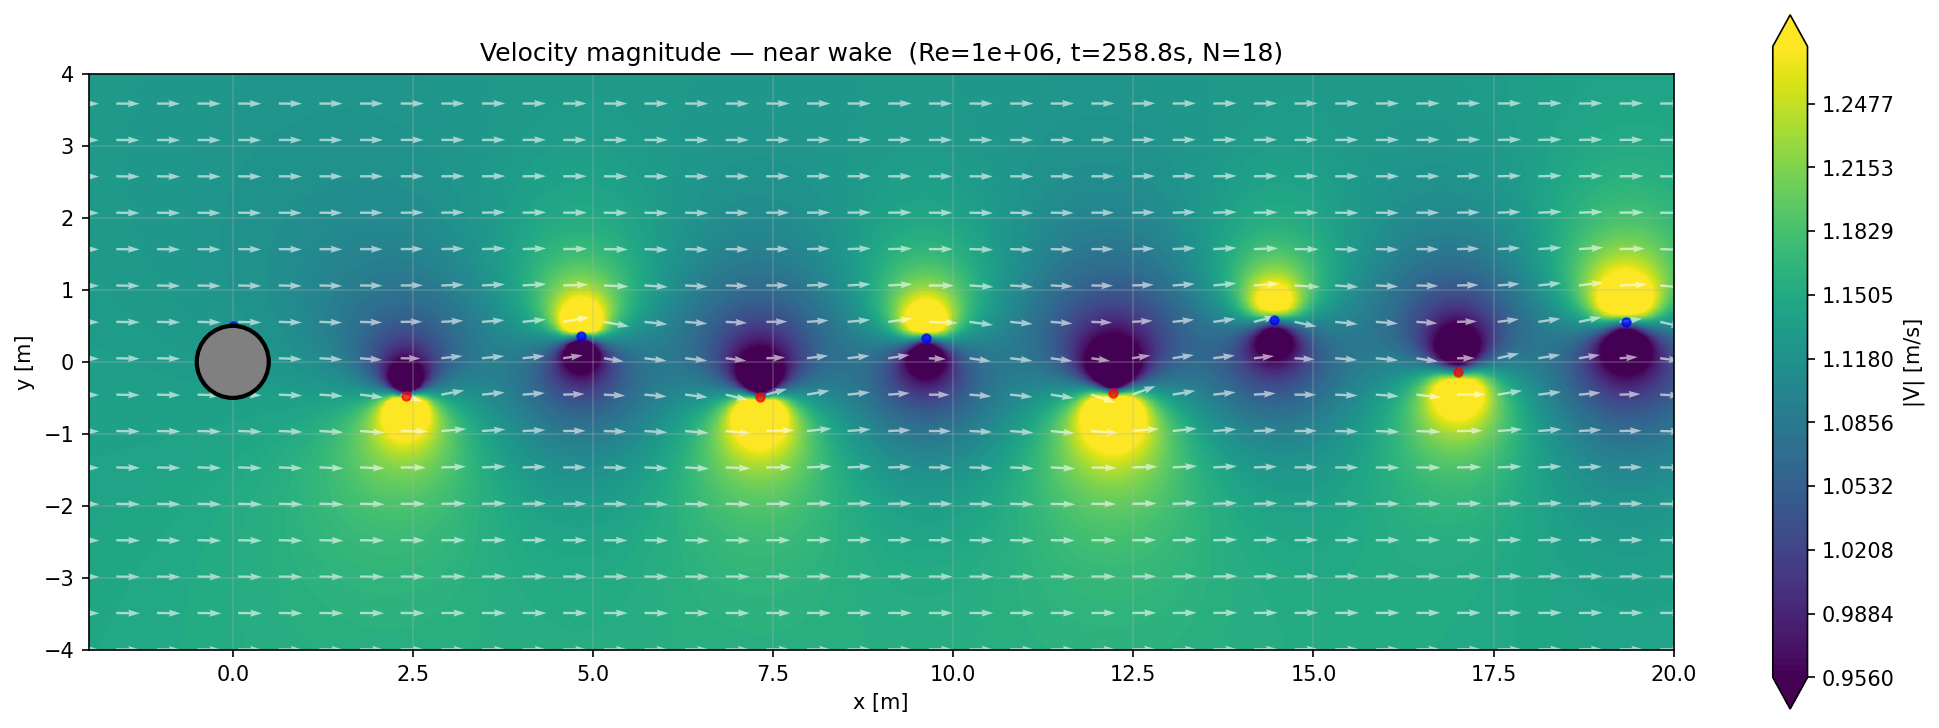

In [26]:
# Pick last saved snapshot
snap_idx = results[results['vortex_field'].notna()].index[-1]
vortex_field = results.loc[snap_idx, 'vortex_field']
snap_time = results.loc[snap_idx, 'time']

# Build velocity on regular grid
nx, ny = 400, 100
gx = np.linspace(X_MIN, X_MAX, nx)
gy = np.linspace(Y_MIN, Y_MAX, ny)
X, Y = np.meshgrid(gx, gy)

U, V = compute_velocity_field(X, Y, vortex_field, U_INF, flow_angle=0.0)
vel_mag = np.sqrt(U**2 + V**2)

# --- Near-wake velocity field ---
fig, ax = plt.subplots(figsize=(14, 5))

# Use tight data range so the colormap resolves actual variations
vmin = np.percentile(vel_mag, 1)
vmax = np.percentile(vel_mag, 99)
cf = ax.contourf(X, Y, vel_mag, levels=np.linspace(vmin, vmax, 100),
                 cmap='viridis', extend='both')
plt.colorbar(cf, ax=ax, label='|V| [m/s]')

skip = 5
ax.quiver(X[::skip, ::skip], Y[::skip, ::skip],
          U[::skip, ::skip], V[::skip, ::skip],
          color='white', alpha=0.6, scale=vmax * 60, width=0.0015)

# Plot vortex positions
for v in vortex_field:
    color = 'red' if v['gamma'] > 0 else 'blue'
    ax.plot(v['x'], v['y'], 'o', color=color, markersize=4, alpha=0.7)

ax.add_patch(Circle((0, 0), D / 2, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax.set_xlim(-2 * D, 20 * D)
ax.set_ylim(-4 * D, 4 * D)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title(f'Velocity magnitude — near wake  (Re={RE:.0e}, t={snap_time:.1f}s, N={len(vortex_field)})')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/velocity_field_nearwake.png', dpi=300, bbox_inches='tight')
plt.show()

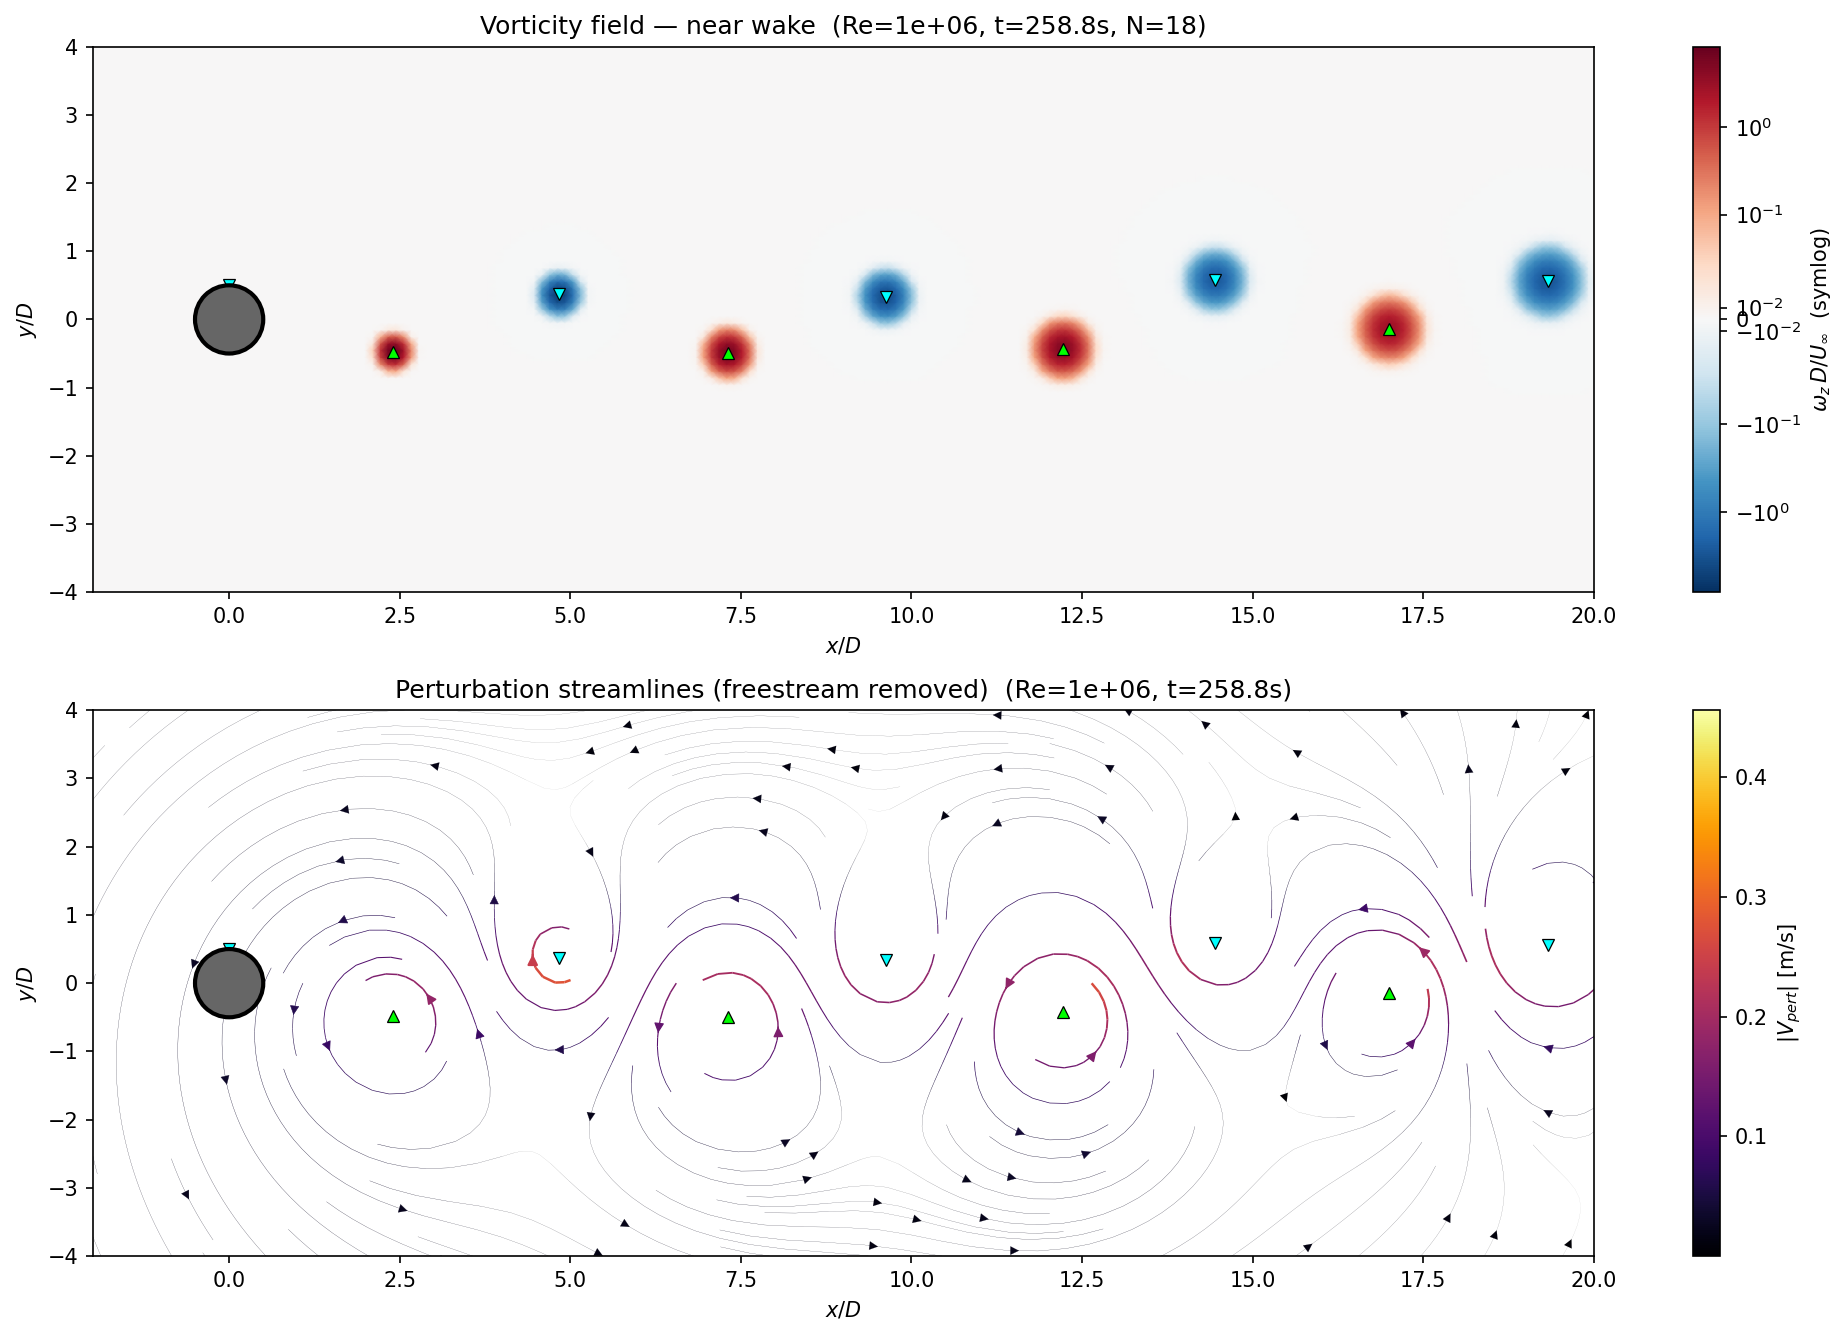

In [37]:
# --- Near-wake vorticity + perturbation streamlines ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

# --- Top: vorticity field (near-wake zoom) with SymLogNorm ---
# Lamb-Oseen vorticity on the existing grid
omega = np.zeros_like(X)
for v in vortex_field:
    r2 = (X - v['x'])**2 + (Y - v['y'])**2
    sigma2 = v['sigma']**2
    omega += (v['gamma'] / (np.pi * sigma2)) * np.exp(-r2 / sigma2)

omega_star = omega * D / U_INF
omega_lim = np.max(np.abs(omega_star))

# SymLogNorm: linear near zero (below linthresh), log-scaled beyond
# linthresh ~ 1% of peak gives good visibility to the weak wake regions
linthresh = 0.01 * omega_lim

norm = SymLogNorm(linthresh=linthresh, vmin=-omega_lim, vmax=omega_lim, base=10)
pcm = ax1.pcolormesh(X / D, Y / D, omega_star, norm=norm,
                      cmap='RdBu_r', shading='gouraud')
plt.colorbar(pcm, ax=ax1, label=r'$\omega_z \, D / U_\infty$  (symlog)')

for v in vortex_field:
    marker = '^' if v['gamma'] > 0 else 'v'
    color = 'lime' if v['gamma'] > 0 else 'cyan'
    ax1.plot(v['x'] / D, v['y'] / D, marker, color=color, ms=6,
             markeredgecolor='black', markeredgewidth=0.6, zorder=10)

ax1.add_patch(Circle((0, 0), 0.5, color='0.4', ec='k', lw=2, zorder=10))
ax1.set_xlim(-2, 20)
ax1.set_ylim(-4, 4)
ax1.set_xlabel('$x / D$')
ax1.set_ylabel('$y / D$')
ax1.set_title(f'Vorticity field — near wake  (Re={RE:.0e}, t={snap_time:.1f}s, N={len(vortex_field)})')
ax1.set_aspect('equal')

# --- Bottom: perturbation streamlines ---
U_pert = U - U_INF
V_pert = V

speed_pert = np.sqrt(U_pert**2 + V_pert**2)
lw = 2 * speed_pert / speed_pert.max()  # linewidth proportional to perturbation speed

strm = ax2.streamplot(gx / D, gy / D, U_pert, V_pert,
                       color=speed_pert, cmap='inferno', linewidth=lw,
                       density=2.5, arrowsize=1.0)
plt.colorbar(strm.lines, ax=ax2, label='$|V_{pert}|$ [m/s]')

for v in vortex_field:
    marker = '^' if v['gamma'] > 0 else 'v'
    color = 'lime' if v['gamma'] > 0 else 'cyan'
    ax2.plot(v['x'] / D, v['y'] / D, marker, color=color, ms=6,
             markeredgecolor='black', markeredgewidth=0.6, zorder=10)

ax2.add_patch(Circle((0, 0), 0.5, color='0.4', ec='k', lw=2, zorder=10))
ax2.set_xlim(-2, 20)
ax2.set_ylim(-4, 4)
ax2.set_xlabel('$x / D$')
ax2.set_ylabel('$y / D$')
ax2.set_title(f'Perturbation streamlines (freestream removed)  (Re={RE:.0e}, t={snap_time:.1f}s)')
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/nearwake_vorticity_streamlines.png', dpi=300, bbox_inches='tight')
plt.show()

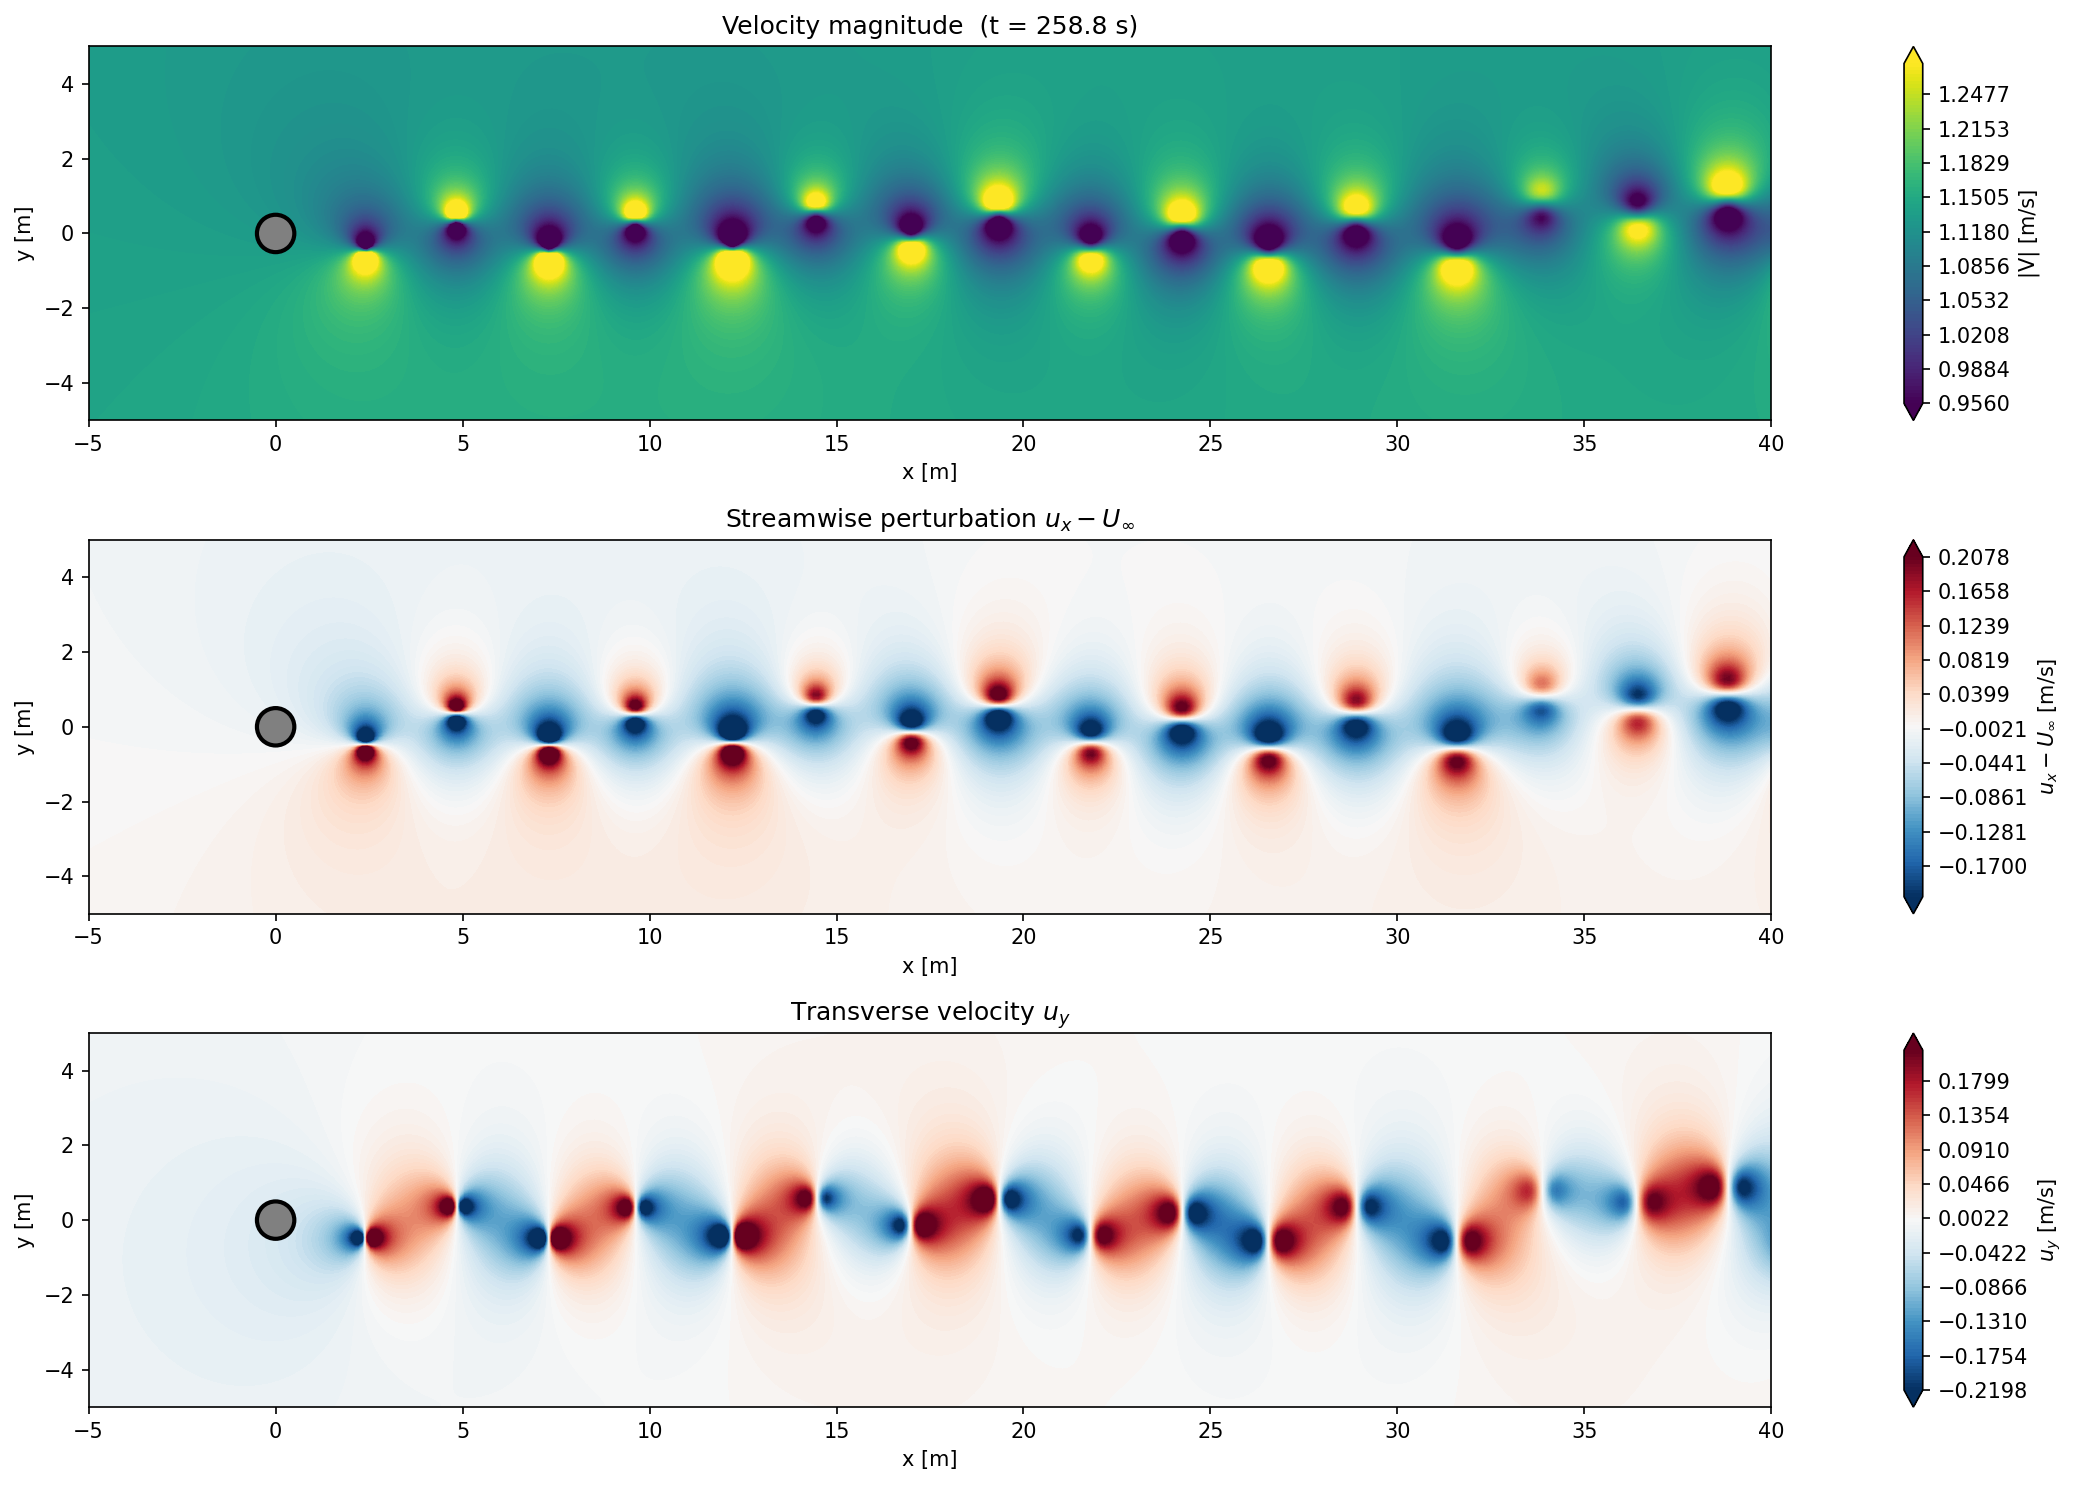

In [21]:
# --- Full-domain velocity components (|V|, u', v) ---
fig, axes = plt.subplots(3, 1, figsize=(18, 10))

# Velocity magnitude — tight range
ax1 = axes[0]
vmin = np.percentile(vel_mag, 1)
vmax = np.percentile(vel_mag, 99)
cf1 = ax1.contourf(X, Y, vel_mag, levels=np.linspace(vmin, vmax, 100),
                   cmap='viridis', extend='both')
plt.colorbar(cf1, ax=ax1, label='|V| [m/s]')
ax1.add_patch(Circle((0, 0), D / 2, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax1.set_xlim(X_MIN, X_MAX)
ax1.set_ylim(Y_MIN, Y_MAX)
ax1.set_title(f'Velocity magnitude  (t = {snap_time:.1f} s)')
ax1.set_xlabel('x [m]')
ax1.set_ylabel('y [m]')
ax1.set_aspect('equal')

# u-perturbation (u - U_inf) so diverging colormap centres on zero
U_prime = U - U_INF
ax2 = axes[1]
u_lim = np.percentile(np.abs(U_prime), 99)
cf2 = ax2.contourf(X, Y, U_prime, levels=np.linspace(-u_lim, u_lim, 100),
                   cmap='RdBu_r', extend='both')
plt.colorbar(cf2, ax=ax2, label="$u_x - U_\\infty$ [m/s]")
ax2.add_patch(Circle((0, 0), D / 2, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax2.set_xlim(X_MIN, X_MAX)
ax2.set_ylim(Y_MIN, Y_MAX)
ax2.set_title("Streamwise perturbation $u_x - U_\\infty$")
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
ax2.set_aspect('equal')

# v-component (already centred at zero)
ax3 = axes[2]
v_lim = np.percentile(np.abs(V), 99)
cf3 = ax3.contourf(X, Y, V, levels=np.linspace(-v_lim, v_lim, 100),
                   cmap='RdBu_r', extend='both')
plt.colorbar(cf3, ax=ax3, label='$u_y$ [m/s]')
ax3.add_patch(Circle((0, 0), D / 2, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax3.set_xlim(X_MIN, X_MAX)
ax3.set_ylim(Y_MIN, Y_MAX)
ax3.set_title('Transverse velocity $u_y$')
ax3.set_xlabel('x [m]')
ax3.set_ylabel('y [m]')
ax3.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/velocity_components.png', dpi=300, bbox_inches='tight')
plt.show()

## Probe Locations

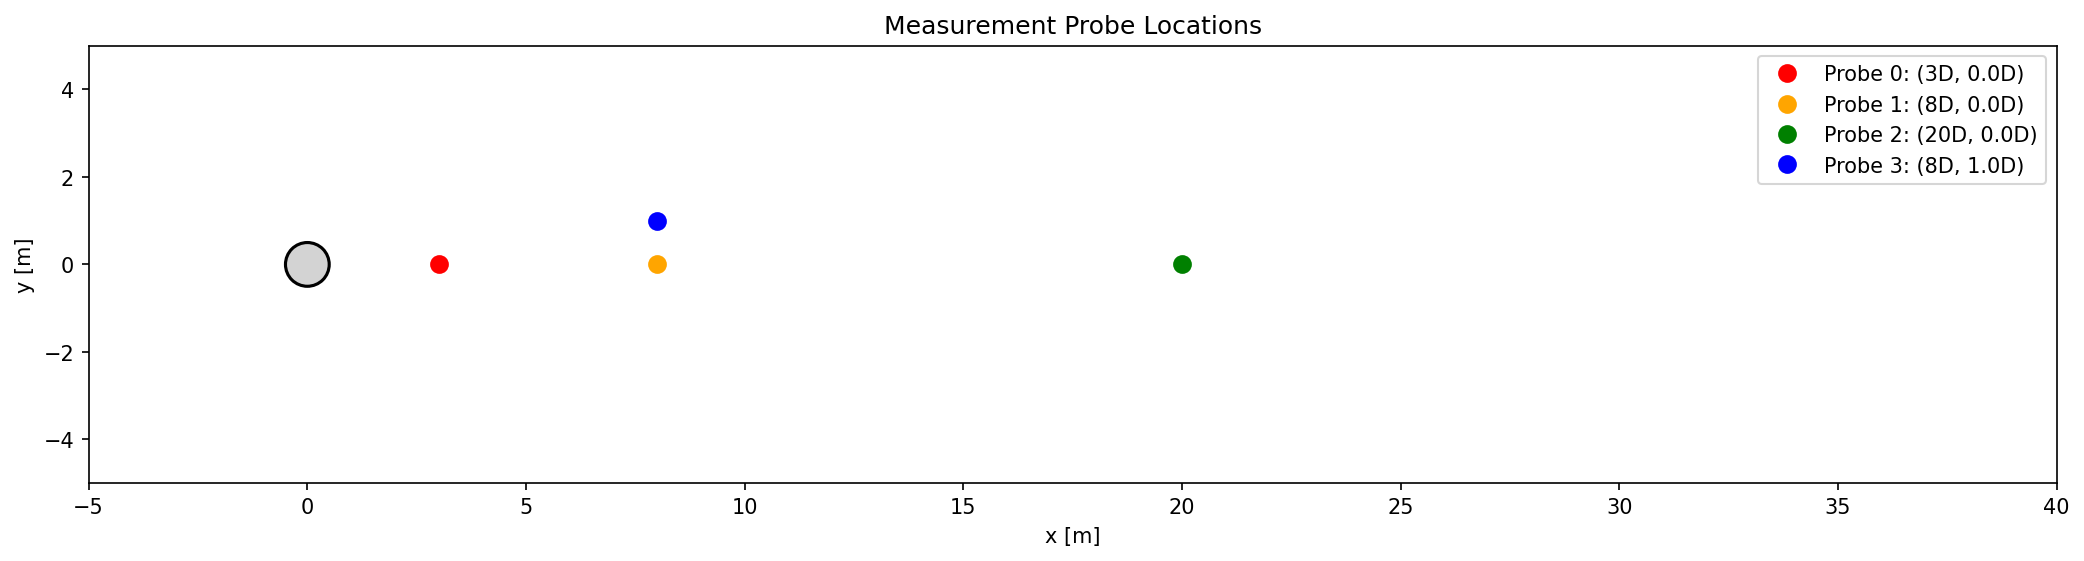

In [22]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.add_patch(Circle((0, 0), D / 2, color='lightgray', ec='k', lw=1.5, zorder=5))

colors = ['red', 'orange', 'green', 'blue']
for i, (px, py) in enumerate(measurement_points):
    ax.plot(px, py, 'o', color=colors[i], ms=8, zorder=6,
            label=f'Probe {i}: ({px/D:.0f}D, {py/D:.1f}D)')

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Measurement Probe Locations')
ax.legend(loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/probe_locations.png', bbox_inches='tight')
plt.show()

## Probe Velocity Time Series

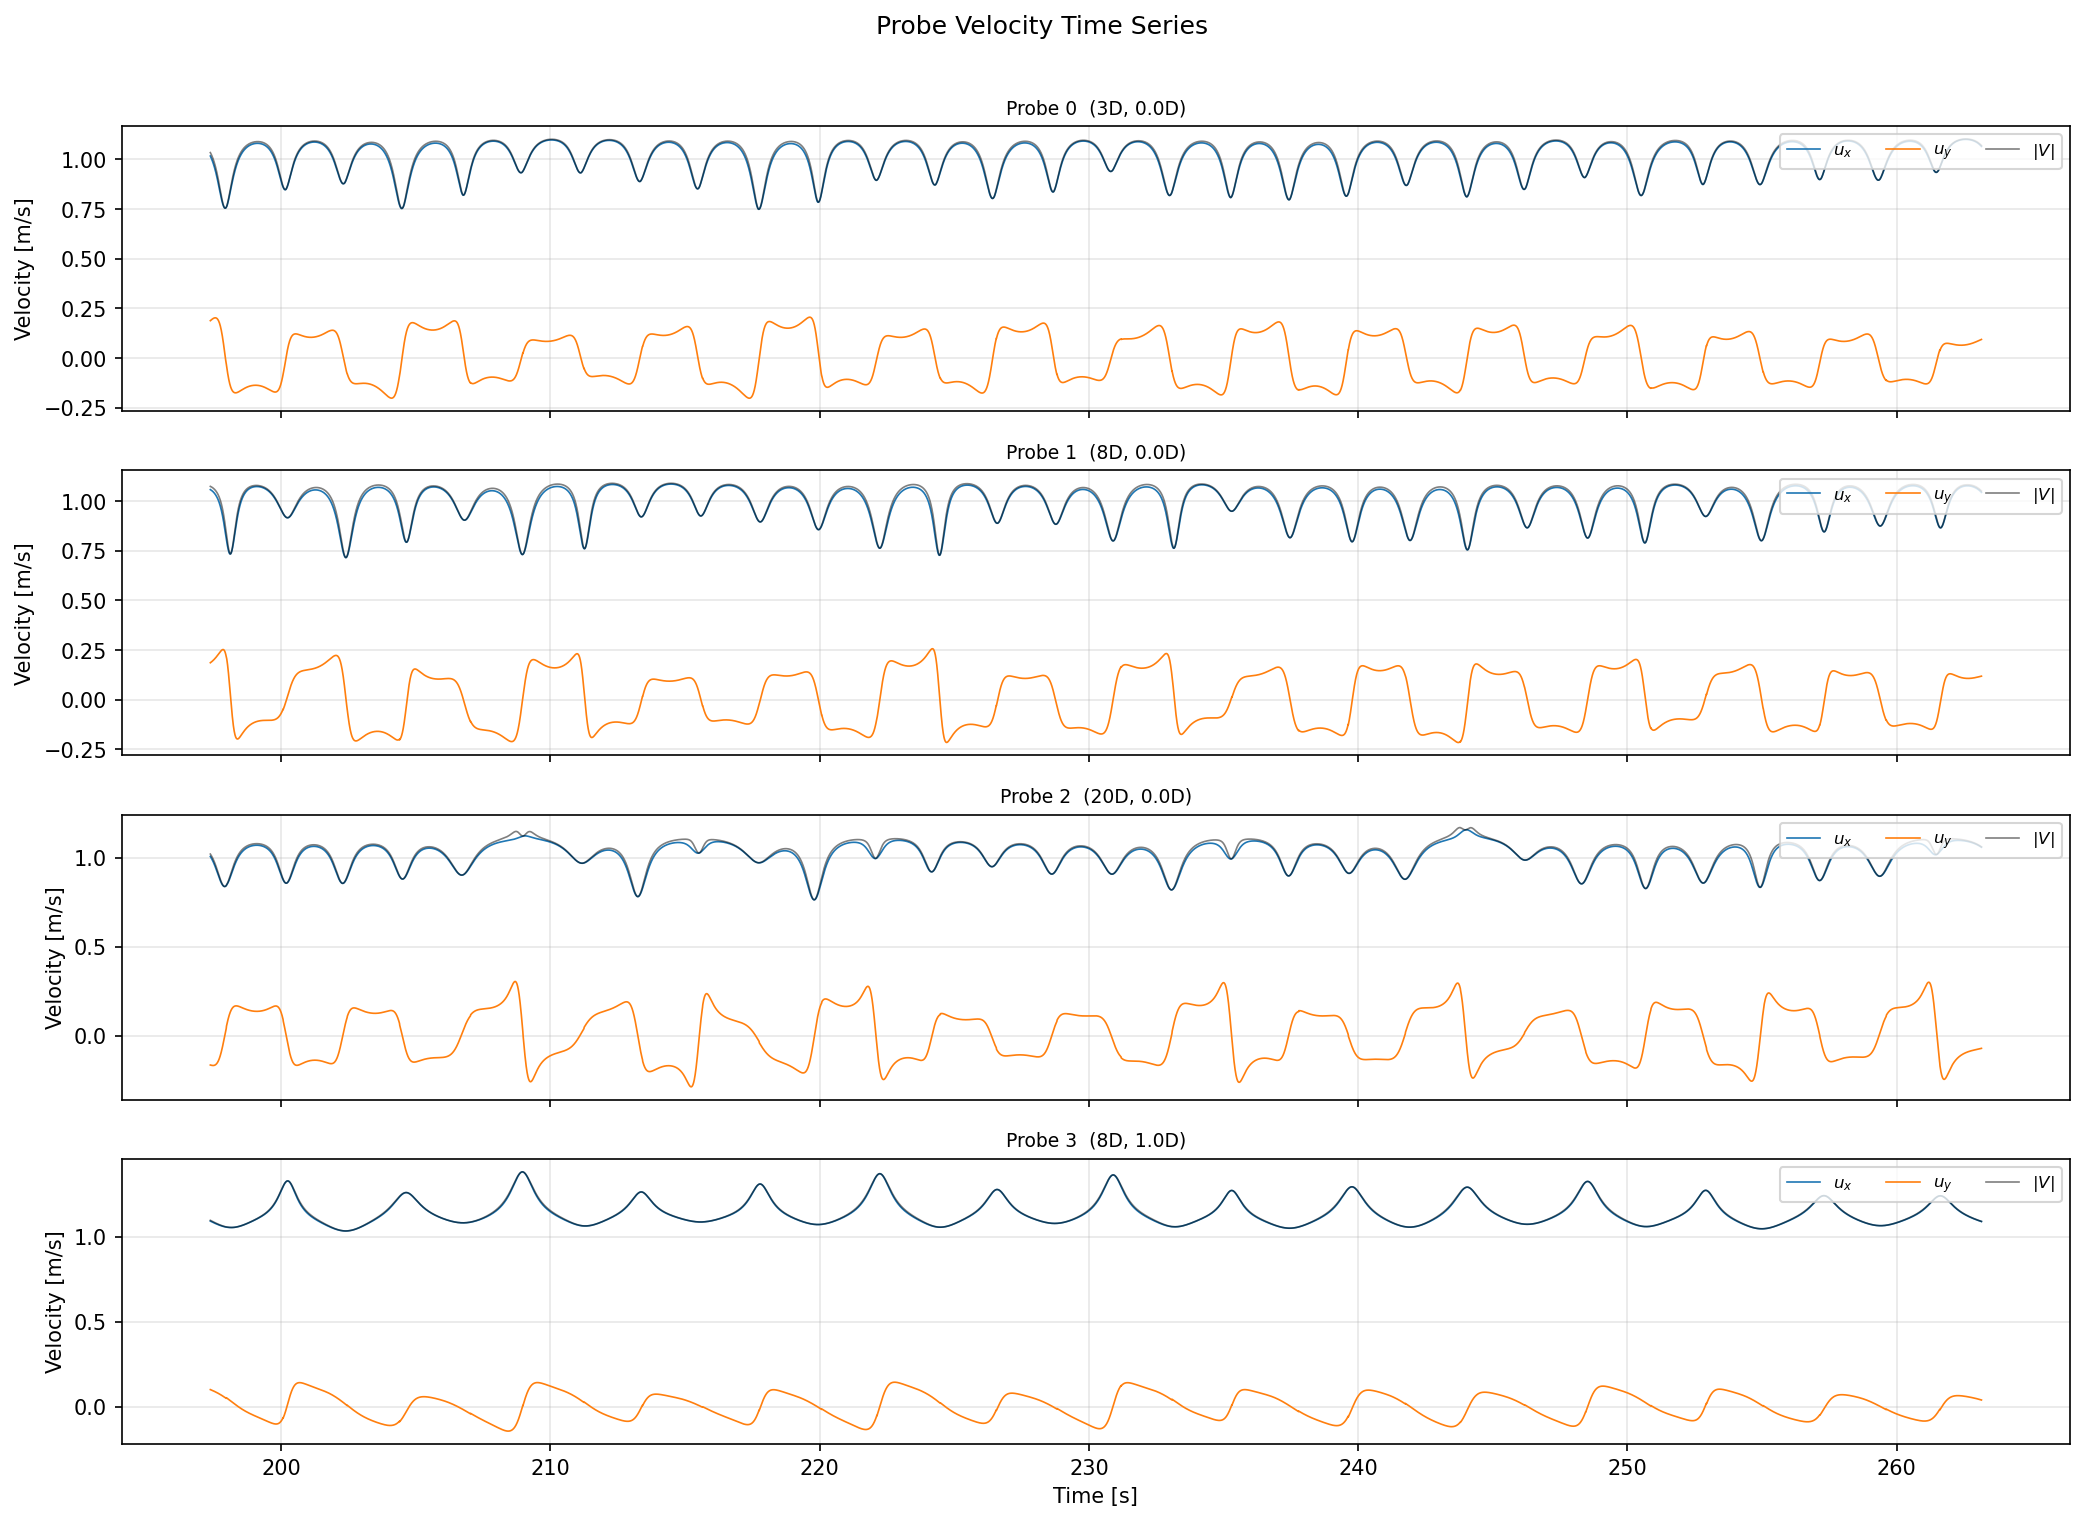

In [23]:
time_arr = results['time'].values

# Show last 15 shedding cycles
t_start = max(0, TOTAL_TIME - 15 * T_SHED)
mask = time_arr >= t_start

fig, axes = plt.subplots(len(measurement_points), 1,
                         figsize=(14, 2.5 * len(measurement_points)), sharex=True)

for i, (px, py) in enumerate(measurement_points):
    ax = axes[i]
    ux = results[f'probe_{i}_ux'].values[mask]
    uy = results[f'probe_{i}_uy'].values[mask]
    vmag = results[f'probe_{i}_vmag'].values[mask]

    ax.plot(time_arr[mask], ux,   lw=0.8, label='$u_x$')
    ax.plot(time_arr[mask], uy,   lw=0.8, label='$u_y$')
    ax.plot(time_arr[mask], vmag, lw=0.8, label='$|V|$', color='k', alpha=0.5)

    ax.set_ylabel('Velocity [m/s]')
    ax.set_title(f'Probe {i}  ({px/D:.0f}D, {py/D:.1f}D)', fontsize=9)
    ax.legend(loc='upper right', fontsize=8, ncol=3)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time [s]')
plt.suptitle('Probe Velocity Time Series', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/probe_velocities.png', bbox_inches='tight')
plt.show()

## Vorticity Field

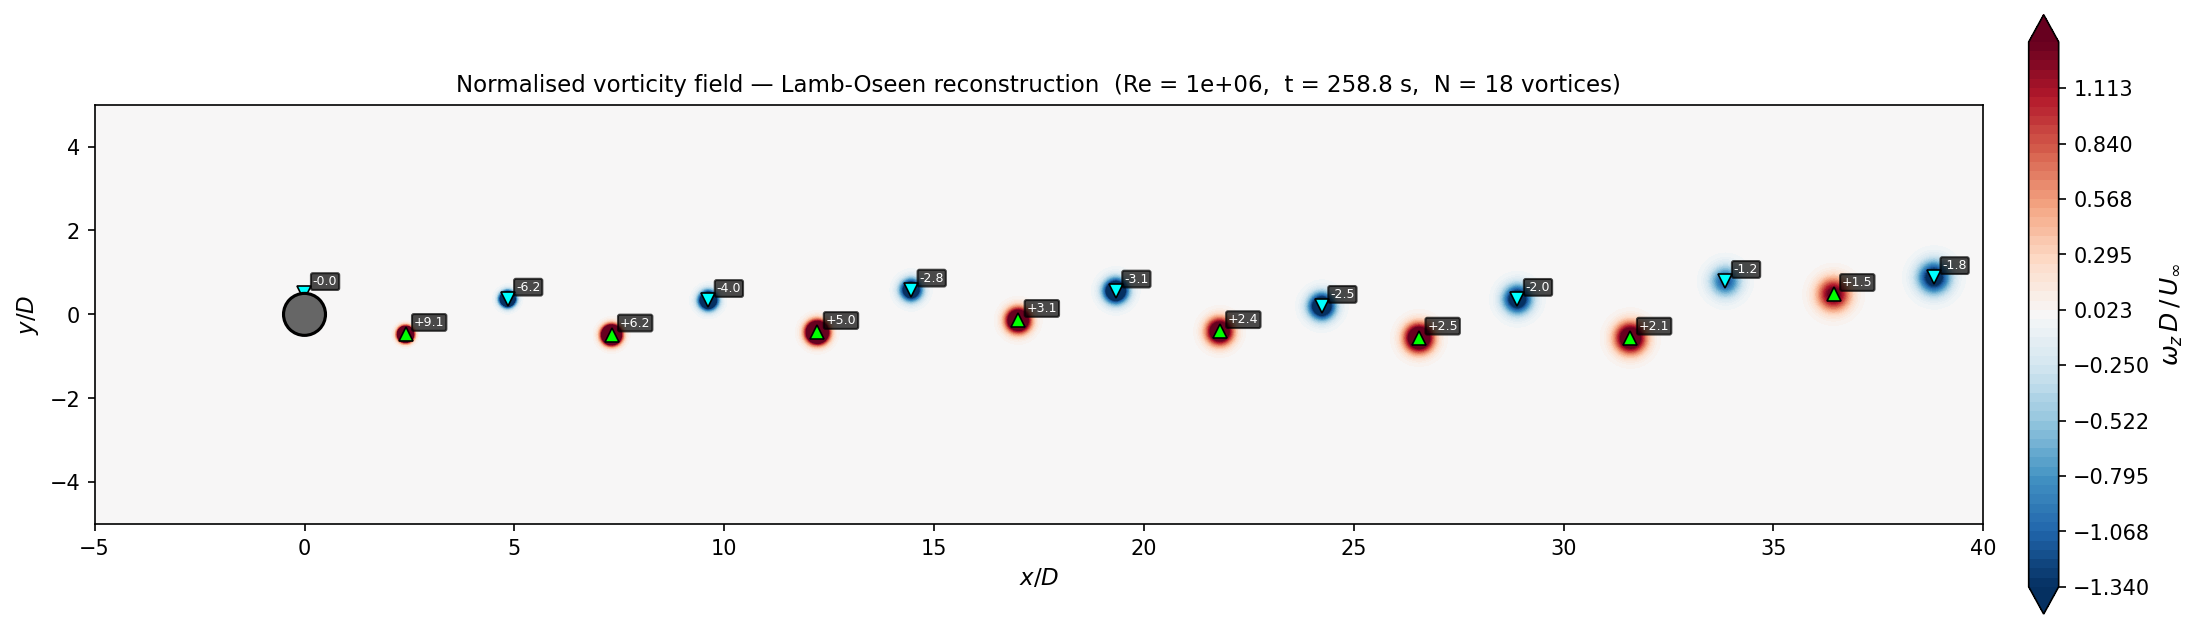

In [24]:
# Vorticity from Lamb-Oseen analytical formula: omega = (Gamma / pi*sigma^2) * exp(-r^2/sigma^2)

nx_fine, ny_fine = 800, 200
x_fine = np.linspace(X_MIN, X_MAX, nx_fine)
y_fine = np.linspace(Y_MIN, Y_MAX, ny_fine)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine)

vm_vorticity = np.zeros_like(X_fine)
for v in vortex_field:
    r2 = (X_fine - v['x'])**2 + (Y_fine - v['y'])**2
    sigma2 = v['sigma']**2
    vm_vorticity += (v['gamma'] / (np.pi * sigma2)) * np.exp(-r2 / sigma2)

# Normalise: omega* = omega * D / U_inf
omega_star = vm_vorticity * D / U_INF

# Linear symmetric colorbar — clip to a sensible range so vortex structure is visible
omega_lim = np.percentile(np.abs(omega_star), 99.5)
levels = np.linspace(-omega_lim, omega_lim, 60)

fig, ax = plt.subplots(figsize=(16, 5))
cf = ax.contourf(X_fine / D, Y_fine / D, omega_star, levels=levels,
                 cmap='RdBu_r', extend='both')
cbar = plt.colorbar(cf, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label(r'$\omega_z \, D \, / \, U_\infty$', fontsize=12)

# Mark vortex cores with contrasting markers
for v in vortex_field:
    marker = '^' if v['gamma'] > 0 else 'v'
    color = 'lime' if v['gamma'] > 0 else 'cyan'
    omega_peak = v['gamma'] / (np.pi * v['sigma']**2) * D / U_INF
    ax.plot(v['x'] / D, v['y'] / D, marker, color=color, ms=7,
            markeredgecolor='black', markeredgewidth=0.8, zorder=10)
    ax.annotate(f'{omega_peak:+.1f}', (v['x'] / D, v['y'] / D),
                xytext=(4, 4), textcoords='offset points', fontsize=6, color='white',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.7),
                zorder=11)

ax.add_patch(Circle((0, 0), 0.5, color='0.4', ec='k', lw=1.5, zorder=10))
ax.set_xlim(X_MIN / D, X_MAX / D)
ax.set_ylim(Y_MIN / D, Y_MAX / D)
ax.set_xlabel('$x / D$', fontsize=11)
ax.set_ylabel('$y / D$', fontsize=11)
ax.set_title(f'Normalised vorticity field — Lamb-Oseen reconstruction  '
             f'(Re = {RE:.0e},  t = {snap_time:.1f} s,  N = {len(vortex_field)} vortices)',
             fontsize=11)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/vorticity_field.png', dpi=300, bbox_inches='tight')
plt.show()